In [1]:
# ============================================================
# 6 : LIGHTGBM REGRESSION — GOLD NEXT-DAY RETURN PREDICTION
# ============================================================
# Pipeline:
#   Load splits → Baseline LGB → Evaluate → Feature Importance
#   → Feature Selection → Retrain → Regime Analysis → Visualize
# ============================================================

import pandas as pd
import numpy as np
import warnings
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyArrowPatch
import matplotlib.ticker as mticker
warnings.filterwarnings("ignore")

import lightgbm as lgb
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.feature_selection import SelectFromModel
from sklearn.inspection import permutation_importance

# ── reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


# ============================================================
# 1 : LOAD SPLITS
# ============================================================
print("=" * 60)
print("1 : LOAD SPLITS")
print("=" * 60)

BASE = "../../../data/processed/splits/"

X_train = pd.read_csv(BASE + "X_train.csv", parse_dates=["Date"], index_col="Date")
X_val   = pd.read_csv(BASE + "X_val.csv",   parse_dates=["Date"], index_col="Date")
X_test  = pd.read_csv(BASE + "X_test.csv",  parse_dates=["Date"], index_col="Date")

y_train = pd.read_csv(BASE + "y_train_reg.csv", parse_dates=["Date"], index_col="Date").squeeze()
y_val   = pd.read_csv(BASE + "y_val_reg.csv",   parse_dates=["Date"], index_col="Date").squeeze()
y_test  = pd.read_csv(BASE + "y_test_reg.csv",  parse_dates=["Date"], index_col="Date").squeeze()

# ── Sanity checks
assert X_train.index.is_monotonic_increasing, "Train index ไม่ได้เรียงตามเวลา!"
assert X_val.index.is_monotonic_increasing,   "Val   index ไม่ได้เรียงตามเวลา!"
assert X_test.index.is_monotonic_increasing,  "Test  index ไม่ได้เรียงตามเวลา!"
assert X_train.index.max() < X_val.index.min(),  "Train/Val overlap!"
assert X_val.index.max()   < X_test.index.min(), "Val/Test overlap!"
assert X_train.isnull().sum().sum() == 0, "NaN in X_train!"
assert X_val.isnull().sum().sum()   == 0, "NaN in X_val!"
assert X_test.isnull().sum().sum()  == 0, "NaN in X_test!"

print(f"  X_train : {X_train.shape}  ({X_train.index.min().date()} → {X_train.index.max().date()})")
print(f"  X_val   : {X_val.shape}    ({X_val.index.min().date()} → {X_val.index.max().date()})")
print(f"  X_test  : {X_test.shape}   ({X_test.index.min().date()} → {X_test.index.max().date()})")
print(f"  y stats : mean={y_train.mean():.4f}  std={y_train.std():.4f}")
print("  ✔ All sanity checks passed\n")


# ============================================================
# 2 : HELPER — METRICS
# ============================================================
def evaluate(name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    # Direction accuracy (ทิศทาง +/-)
    dir_acc = np.mean(np.sign(y_true) == np.sign(y_pred)) * 100
    print(f"  [{name}]  RMSE={rmse:.4f}  MAE={mae:.4f}  R²={r2:.4f}  DirAcc={dir_acc:.1f}%")
    return {"rmse": rmse, "mae": mae, "r2": r2, "dir_acc": dir_acc}


# ============================================================
# 3 : BASELINE LIGHTGBM (FULL FEATURES)
# ============================================================
print("=" * 60)
print("3 : BASELINE LIGHTGBM — FULL FEATURES")
print("=" * 60)

params_base = dict(
    n_estimators      = 1000,
    learning_rate     = 0.03,
    num_leaves        = 31,          # 2^max_depth แนวทาง: ไม่เกิน 2^(max_depth)
    max_depth         = 6,
    min_child_samples = 30,          # ป้องกัน overfit (financial data noisy มาก)
    subsample         = 0.8,         # row sampling ต่อ tree
    colsample_bytree  = 0.7,         # column sampling ต่อ tree
    reg_alpha         = 0.1,         # L1 regularization
    reg_lambda        = 1.0,         # L2 regularization
    random_state      = RANDOM_STATE,
    n_jobs            = -1,
    verbose           = -1,
)

model_base = lgb.LGBMRegressor(**params_base)

# early stopping: หยุดถ้า val loss ไม่ดีขึ้น 50 rounds
callbacks = [
    lgb.early_stopping(stopping_rounds=50, verbose=False),
    lgb.log_evaluation(period=100),
]

model_base.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=callbacks,
)

best_iter = model_base.best_iteration_
print(f"\n  Best iteration: {best_iter}")

y_pred_train_base = model_base.predict(X_train)
y_pred_val_base   = model_base.predict(X_val)
y_pred_test_base  = model_base.predict(X_test)

print("\n  --- Baseline Performance ---")
m_train_base = evaluate("Train", y_train, y_pred_train_base)
m_val_base   = evaluate("Val  ", y_val,   y_pred_val_base)
m_test_base  = evaluate("Test ", y_test,  y_pred_test_base)

overfit_gap = m_train_base["rmse"] - m_val_base["rmse"]
print(f"\n  Overfit gap (Train RMSE - Val RMSE): {overfit_gap:.4f}")
if abs(overfit_gap) > 0.05:
    print("  ⚠  Gap สูง → โมเดลอาจ overfit บน Train")
else:
    print("  ✔  Gap เล็กน้อย → generalize ดี")


# ============================================================
# 4 : FEATURE IMPORTANCE (BASELINE)
# ============================================================
print("\n" + "=" * 60)
print("4 : FEATURE IMPORTANCE (BASELINE)")
print("=" * 60)

feat_imp = pd.Series(
    model_base.feature_importances_,
    index=X_train.columns,
).sort_values(ascending=False)

print(f"\n  Top 20 features:")
print(feat_imp.head(20).to_string())

print(f"\n  Features with importance = 0: {(feat_imp == 0).sum()} features")
print(f"  Features with importance < 10: {(feat_imp < 10).sum()} features")


# ============================================================
# 5 : FEATURE SELECTION
# ============================================================
print("\n" + "=" * 60)
print("5 : FEATURE SELECTION")
print("=" * 60)

# Strategy: ใช้ threshold = median importance
# เหตุผล: conservative — เก็บ features ที่ดีกว่าครึ่งหนึ่ง
# ไม่ aggressive เกินไปเพราะ financial signal มี noise สูง
threshold_imp = feat_imp.median()
print(f"  Threshold (median importance): {threshold_imp:.2f}")

selected_features = feat_imp[feat_imp >= threshold_imp].index.tolist()
dropped_features  = feat_imp[feat_imp < threshold_imp].index.tolist()

print(f"  Features before selection : {len(X_train.columns)}")
print(f"  Features selected         : {len(selected_features)}")
print(f"  Features dropped          : {len(dropped_features)}")
print(f"\n  Dropped features (low importance):")
for f in dropped_features:
    print(f"    - {f}  (importance={feat_imp[f]:.1f})")

X_train_sel = X_train[selected_features]
X_val_sel   = X_val[selected_features]
X_test_sel  = X_test[selected_features]


# ============================================================
# 6 : RETRAIN WITH SELECTED FEATURES
# ============================================================
print("\n" + "=" * 60)
print("6 : RETRAIN WITH SELECTED FEATURES")
print("=" * 60)

model_sel = lgb.LGBMRegressor(**params_base)

model_sel.fit(
    X_train_sel, y_train,
    eval_set=[(X_val_sel, y_val)],
    callbacks=callbacks,
)

best_iter_sel = model_sel.best_iteration_
print(f"\n  Best iteration: {best_iter_sel}")

y_pred_train_sel = model_sel.predict(X_train_sel)
y_pred_val_sel   = model_sel.predict(X_val_sel)
y_pred_test_sel  = model_sel.predict(X_test_sel)

print("\n  --- Selected Features Performance ---")
m_train_sel = evaluate("Train", y_train, y_pred_train_sel)
m_val_sel   = evaluate("Val  ", y_val,   y_pred_val_sel)
m_test_sel  = evaluate("Test ", y_test,  y_pred_test_sel)


# ============================================================
# 7 : COMPARISON TABLE
# ============================================================
print("\n" + "=" * 60)
print("7 : COMPARISON — BASELINE vs SELECTED FEATURES")
print("=" * 60)

comparison = pd.DataFrame({
    "Model": ["Baseline (Full)", "Selected Features"],
    "n_features": [len(X_train.columns), len(selected_features)],
    "Val RMSE":  [m_val_base["rmse"],   m_val_sel["rmse"]],
    "Val MAE":   [m_val_base["mae"],    m_val_sel["mae"]],
    "Val R²":    [m_val_base["r2"],     m_val_sel["r2"]],
    "Test RMSE": [m_test_base["rmse"],  m_test_sel["rmse"]],
    "Test MAE":  [m_test_base["mae"],   m_test_sel["mae"]],
    "Test R²":   [m_test_base["r2"],    m_test_sel["r2"]],
    "Test DirAcc%": [m_test_base["dir_acc"], m_test_sel["dir_acc"]],
})
print(comparison.to_string(index=False))

# คำแนะนำอัตโนมัติ
val_rmse_diff = m_val_sel["rmse"] - m_val_base["rmse"]
test_rmse_diff = m_test_sel["rmse"] - m_test_base["rmse"]
print(f"\n  Val  RMSE change : {val_rmse_diff:+.4f}  ({'worse' if val_rmse_diff > 0 else 'better'})")
print(f"  Test RMSE change : {test_rmse_diff:+.4f}  ({'worse' if test_rmse_diff > 0 else 'better'})")

if test_rmse_diff <= 0:
    print("  ✔  Feature Selection ช่วยให้ Test performance ดีขึ้น → ใช้ selected model")
    best_model    = model_sel
    best_X_val    = X_val_sel
    best_X_test   = X_test_sel
    best_X_train  = X_train_sel
    best_pred_val  = y_pred_val_sel
    best_pred_test = y_pred_test_sel
    best_label    = "Selected Features"
else:
    print("  ⚠  Feature Selection ไม่ช่วย → ใช้ baseline model")
    best_model    = model_base
    best_X_val    = X_val
    best_X_test   = X_test
    best_X_train  = X_train
    best_pred_val  = y_pred_val_base
    best_pred_test = y_pred_test_base
    best_label    = "Baseline (Full Features)"


# ============================================================
# 8 : REGIME ANALYSIS — feature importance เปลี่ยนตาม regime?
# ============================================================
print("\n" + "=" * 60)
print("8 : REGIME ANALYSIS — Feature Importance per Regime")
print("=" * 60)

# กำหนด regime โดยใช้ rolling volatility ของ target
# High Vol regime = volatility > median volatility
rolling_vol = y_train.rolling(60).std()
vol_median  = rolling_vol.median()

regime_mask_high = rolling_vol > vol_median
regime_mask_low  = ~regime_mask_high

X_train_high = X_train_sel[regime_mask_high.fillna(False)]
y_train_high = y_train[regime_mask_high.fillna(False)]

X_train_low  = X_train_sel[regime_mask_low.fillna(False)]
y_train_low  = y_train[regime_mask_low.fillna(False)]

print(f"  High Volatility regime : {len(X_train_high)} rows "
      f"({len(X_train_high)/len(X_train)*100:.1f}%)")
print(f"  Low  Volatility regime : {len(X_train_low)} rows "
      f"({len(X_train_low)/len(X_train)*100:.1f}%)")

# Train lightweight models per regime
params_regime = dict(
    n_estimators=300, learning_rate=0.05, num_leaves=16,
    max_depth=4, min_child_samples=15, random_state=RANDOM_STATE,
    verbose=-1, n_jobs=-1,
)

model_high = lgb.LGBMRegressor(**params_regime)
model_high.fit(X_train_high, y_train_high)
imp_high = pd.Series(model_high.feature_importances_, index=selected_features)

model_low  = lgb.LGBMRegressor(**params_regime)
model_low.fit(X_train_low, y_train_low)
imp_low  = pd.Series(model_low.feature_importances_, index=selected_features)

# เปรียบเทียบ top features per regime
regime_df = pd.DataFrame({
    "High_Vol_Importance": imp_high,
    "Low_Vol_Importance" : imp_low,
}).sort_values("High_Vol_Importance", ascending=False)

# Regime shift score = absolute difference in importance ranks
regime_df["High_Vol_Rank"] = imp_high.rank(ascending=False)
regime_df["Low_Vol_Rank"]  = imp_low.rank(ascending=False)
regime_df["Rank_Shift"]    = (regime_df["High_Vol_Rank"] - regime_df["Low_Vol_Rank"]).abs()

# Robust features = ไม่เปลี่ยน rank มาก
robust_features = regime_df[regime_df["Rank_Shift"] < 5].index.tolist()
volatile_features = regime_df[regime_df["Rank_Shift"] >= 15].index.tolist()

print(f"\n  Top 10 Features (High Volatility Regime):")
print(imp_high.sort_values(ascending=False).head(10).to_string())

print(f"\n  Top 10 Features (Low Volatility Regime):")
print(imp_low.sort_values(ascending=False).head(10).to_string())

print(f"\n  Robust features (Rank shift < 5): {len(robust_features)} features")
print(f"  {robust_features}")

print(f"\n  Regime-sensitive features (Rank shift ≥ 15): {len(volatile_features)} features")
print(f"  {volatile_features}")







1 : LOAD SPLITS
  X_train : (1479, 69)  (2016-02-12 → 2021-12-31)
  X_val   : (501, 69)    (2022-01-03 → 2023-12-29)
  X_test  : (563, 69)   (2024-01-02 → 2026-03-27)
  y stats : mean=0.0416  std=0.7022
  ✔ All sanity checks passed

3 : BASELINE LIGHTGBM — FULL FEATURES

  Best iteration: 1

  --- Baseline Performance ---
  [Train]  RMSE=0.7007  MAE=0.5292  R²=0.0036  DirAcc=51.4%
  [Val  ]  RMSE=0.7644  MAE=0.5866  R²=-0.0004  DirAcc=49.9%
  [Test ]  RMSE=0.8349  MAE=0.6476  R²=-0.0416  DirAcc=54.2%

  Overfit gap (Train RMSE - Val RMSE): -0.0637
  ⚠  Gap สูง → โมเดลอาจ overfit บน Train

4 : FEATURE IMPORTANCE (BASELINE)

  Top 20 features:
f_gold_close_ret         1
f_real_rate_chg_1m       1
f_dxy_close_ret          1
f_corr_90d_dxy           1
f_gold_vol_5d            1
f_log_gold_close         1
f_gold_roc_10d           1
f_oil_gold_ratio         1
f_gold_ret_lag2          1
f_vix_close_ret          1
f_vix_trend_20d          0
f_dxy_trend_60d          0
f_gold_oil_spread_ret    0


9 : VISUALIZATION


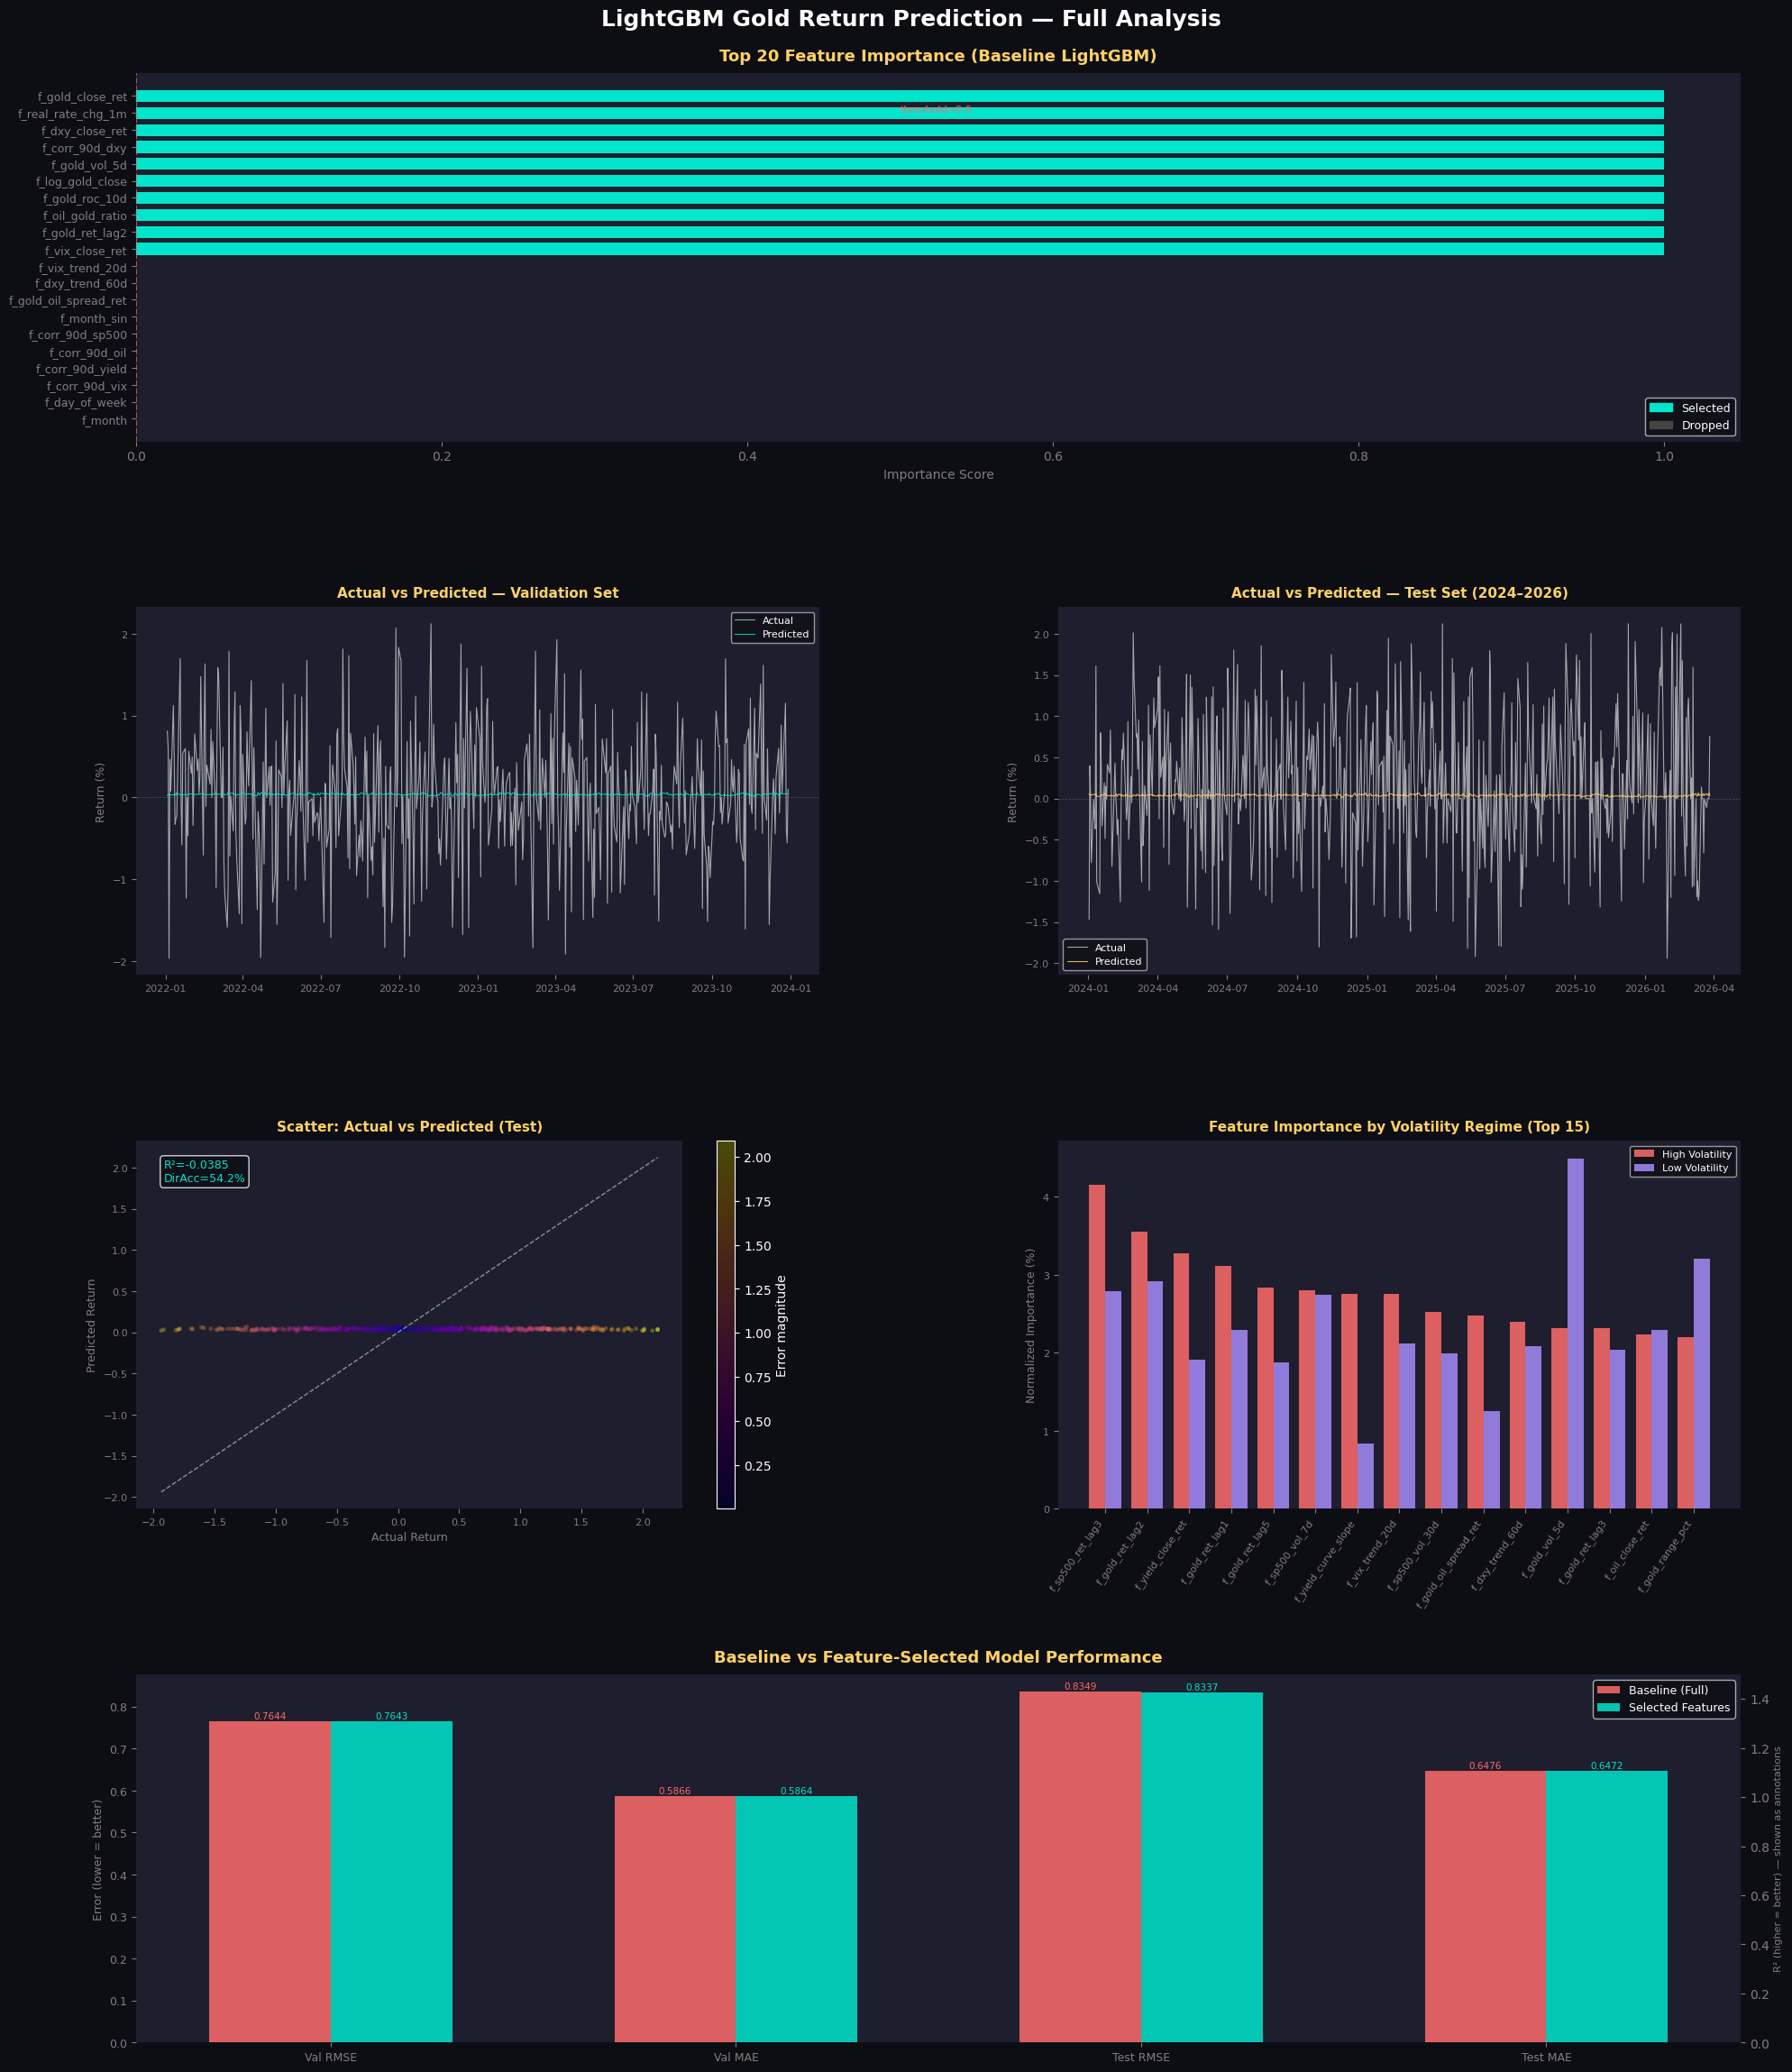

In [2]:
# ============================================================
# 9 : VISUALIZATION
# ============================================================
print("\n" + "=" * 60)
print("9 : VISUALIZATION")
print("=" * 60)

plt.style.use("dark_background")
FIG_COLOR  = "#0D0D14"
ACCENT1    = "#00E5CC"   # teal
ACCENT2    = "#FF6B6B"   # coral
ACCENT3    = "#FFD166"   # gold (เหมาะกับ gold prediction!)
ACCENT4    = "#A78BFA"   # purple
GRID_COLOR = "#1E1E2E"

fig = plt.figure(figsize=(20, 24), facecolor=FIG_COLOR)
fig.suptitle("LightGBM Gold Return Prediction — Full Analysis",
             fontsize=18, color="white", fontweight="bold", y=0.98)

gs = gridspec.GridSpec(4, 2, figure=fig, hspace=0.45, wspace=0.35,
                       left=0.07, right=0.96, top=0.95, bottom=0.04)

# ── Panel 1: Feature Importance (Baseline) — Top 20
ax1 = fig.add_subplot(gs[0, :])
top20 = feat_imp.head(20)
colors_imp = [ACCENT1 if f in selected_features else "#444" for f in top20.index]
bars = ax1.barh(range(len(top20)), top20.values, color=colors_imp, edgecolor="none",
                height=0.7)
ax1.set_yticks(range(len(top20)))
ax1.set_yticklabels(top20.index, fontsize=9, color="white")
ax1.invert_yaxis()
ax1.set_facecolor(GRID_COLOR)
ax1.set_title("Top 20 Feature Importance (Baseline LightGBM)", color=ACCENT3,
              fontsize=13, pad=10, fontweight="bold")
ax1.set_xlabel("Importance Score", color="gray", fontsize=10)
ax1.tick_params(colors="gray")
ax1.spines[:].set_visible(False)
# legend
from matplotlib.patches import Patch
legend_els = [Patch(color=ACCENT1, label="Selected"), Patch(color="#444", label="Dropped")]
ax1.legend(handles=legend_els, loc="lower right", facecolor=FIG_COLOR, labelcolor="white",
           fontsize=9, framealpha=0.8)
# threshold line (median)
ax1.axvline(threshold_imp, color=ACCENT2, linestyle="--", linewidth=1.2, alpha=0.8,
            label=f"Threshold (median={threshold_imp:.1f})")
ax1.text(threshold_imp + 0.5, 0.5, f"threshold={threshold_imp:.1f}",
         color=ACCENT2, fontsize=8, va="top")

# ── Panel 2: Actual vs Predicted — Validation
ax2 = fig.add_subplot(gs[1, 0])
ax2.set_facecolor(GRID_COLOR)
val_dates = X_val.index
ax2.plot(val_dates, y_val.values, color="white", linewidth=0.8, alpha=0.6, label="Actual")
ax2.plot(val_dates, best_pred_val, color=ACCENT1, linewidth=0.8, alpha=0.85, label="Predicted")
ax2.axhline(0, color="gray", linestyle="--", linewidth=0.5, alpha=0.5)
ax2.set_title("Actual vs Predicted — Validation Set", color=ACCENT3, fontsize=11,
              fontweight="bold", pad=8)
ax2.set_ylabel("Return (%)", color="gray", fontsize=9)
ax2.legend(fontsize=8, facecolor=FIG_COLOR, labelcolor="white", framealpha=0.7)
ax2.tick_params(colors="gray", labelsize=8)
ax2.spines[:].set_visible(False)
ax2.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter("%Y-%m"))

# ── Panel 3: Actual vs Predicted — Test
ax3 = fig.add_subplot(gs[1, 1])
ax3.set_facecolor(GRID_COLOR)
test_dates = X_test.index
ax3.plot(test_dates, y_test.values, color="white", linewidth=0.8, alpha=0.6, label="Actual")
ax3.plot(test_dates, best_pred_test, color=ACCENT3, linewidth=0.8, alpha=0.85, label="Predicted")
ax3.axhline(0, color="gray", linestyle="--", linewidth=0.5, alpha=0.5)
ax3.set_title("Actual vs Predicted — Test Set (2024–2026)", color=ACCENT3, fontsize=11,
              fontweight="bold", pad=8)
ax3.set_ylabel("Return (%)", color="gray", fontsize=9)
ax3.legend(fontsize=8, facecolor=FIG_COLOR, labelcolor="white", framealpha=0.7)
ax3.tick_params(colors="gray", labelsize=8)
ax3.spines[:].set_visible(False)
ax3.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter("%Y-%m"))

# ── Panel 4: Scatter Actual vs Predicted (Test)
ax4 = fig.add_subplot(gs[2, 0])
ax4.set_facecolor(GRID_COLOR)
sc = ax4.scatter(y_test.values, best_pred_test, alpha=0.3, s=12,
                 c=np.abs(y_test.values - best_pred_test), cmap="plasma", edgecolors="none")
lims = [min(y_test.min(), best_pred_test.min()), max(y_test.max(), best_pred_test.max())]
ax4.plot(lims, lims, color="white", linewidth=1, alpha=0.5, linestyle="--")
ax4.set_title("Scatter: Actual vs Predicted (Test)", color=ACCENT3, fontsize=11,
              fontweight="bold", pad=8)
ax4.set_xlabel("Actual Return", color="gray", fontsize=9)
ax4.set_ylabel("Predicted Return", color="gray", fontsize=9)
ax4.tick_params(colors="gray", labelsize=8)
ax4.spines[:].set_visible(False)
plt.colorbar(sc, ax=ax4, label="Error magnitude")
ax4.text(0.05, 0.95, f"R²={m_test_sel['r2']:.4f}\nDirAcc={m_test_sel['dir_acc']:.1f}%",
         transform=ax4.transAxes, color=ACCENT1, fontsize=9, va="top",
         bbox=dict(boxstyle="round,pad=0.3", facecolor=FIG_COLOR, alpha=0.8))

# ── Panel 5: Regime Feature Importance — High vs Low Vol
ax5 = fig.add_subplot(gs[2, 1])
ax5.set_facecolor(GRID_COLOR)
top_n = 15
top_high = imp_high.sort_values(ascending=False).head(top_n)
x_pos = np.arange(len(top_high))
width = 0.38
# normalize for fair comparison
imp_high_norm = imp_high / imp_high.sum()
imp_low_norm  = imp_low / imp_low.sum()
top_feats_regime = imp_high_norm.sort_values(ascending=False).head(top_n)
imp_low_aligned   = imp_low_norm[top_feats_regime.index]
ax5.bar(x_pos - width/2, top_feats_regime.values * 100, width, color=ACCENT2,
        alpha=0.85, label="High Volatility", edgecolor="none")
ax5.bar(x_pos + width/2, imp_low_aligned.values * 100, width, color=ACCENT4,
        alpha=0.85, label="Low Volatility", edgecolor="none")
ax5.set_xticks(x_pos)
ax5.set_xticklabels(top_feats_regime.index, rotation=55, ha="right", fontsize=7.5, color="white")
ax5.set_title("Feature Importance by Volatility Regime (Top 15)", color=ACCENT3,
              fontsize=11, fontweight="bold", pad=8)
ax5.set_ylabel("Normalized Importance (%)", color="gray", fontsize=9)
ax5.legend(fontsize=8, facecolor=FIG_COLOR, labelcolor="white", framealpha=0.7)
ax5.tick_params(colors="gray", labelsize=8)
ax5.spines[:].set_visible(False)

# ── Panel 6: Performance Comparison Bar Chart
ax6 = fig.add_subplot(gs[3, :])
ax6.set_facecolor(GRID_COLOR)
metrics_show = ["Val RMSE", "Val MAE", "Test RMSE", "Test MAE"]
vals_base = [m_val_base["rmse"], m_val_base["mae"], m_test_base["rmse"], m_test_base["mae"]]
vals_sel  = [m_val_sel["rmse"],  m_val_sel["mae"],  m_test_sel["rmse"],  m_test_sel["mae"]]
x2 = np.arange(len(metrics_show))
w2 = 0.3
ax6.bar(x2 - w2/2, vals_base, w2, color=ACCENT2, alpha=0.85, label="Baseline (Full)", edgecolor="none")
ax6.bar(x2 + w2/2, vals_sel,  w2, color=ACCENT1, alpha=0.85, label="Selected Features", edgecolor="none")
for xi, (vb, vs) in zip(x2, zip(vals_base, vals_sel)):
    ax6.text(xi - w2/2, vb + 0.002, f"{vb:.4f}", ha="center", va="bottom",
             fontsize=7.5, color=ACCENT2)
    ax6.text(xi + w2/2, vs + 0.002, f"{vs:.4f}", ha="center", va="bottom",
             fontsize=7.5, color=ACCENT1)
ax6.set_xticks(x2)
ax6.set_xticklabels(metrics_show, color="white", fontsize=10)
ax6.set_title("Baseline vs Feature-Selected Model Performance", color=ACCENT3,
              fontsize=13, fontweight="bold", pad=10)
ax6.set_ylabel("Error (lower = better)", color="gray", fontsize=9)
ax6.legend(fontsize=9, facecolor=FIG_COLOR, labelcolor="white", framealpha=0.8)
ax6.tick_params(colors="gray", labelsize=9)
ax6.spines[:].set_visible(False)

# R² annotations
ax6_r2 = ax6.twinx()
ax6_r2.set_facecolor(GRID_COLOR)
ax6_r2.spines[:].set_visible(False)
ax6_r2.set_ylim(0, 1.5)
ax6_r2.tick_params(colors="gray")
ax6_r2.set_ylabel("R² (higher = better) — shown as annotations", color="gray", fontsize=8)
for label, r2_val, color in [
    ("Val R² Baseline",   m_val_base["r2"],  ACCENT2),
    ("Val R² Selected",   m_val_sel["r2"],   ACCENT1),
    ("Test R² Baseline",  m_test_base["r2"], ACCENT2),
    ("Test R² Selected",  m_test_sel["r2"],  ACCENT1),
]:
    pass  # R² shown in text summary instead

# plt.savefig("../data/processed/splits/6_lightgbm_analysis.png",
            # dpi=140, bbox_inches="tight", facecolor=FIG_COLOR)
# print("  ✔ Saved visualization → ../data/processed/splits/6_lightgbm_analysis.png")
plt.tight_layout()
plt.show()

In [3]:
# ============================================================
# 10 : FINAL SUMMARY & RECOMMENDATIONS
# ============================================================
print("\n" + "=" * 60)
print("10 : FINAL SUMMARY & RECOMMENDATIONS")
print("=" * 60)

print(f"""
  ┌─────────────────────────────────────────────────────────┐
  │  BEST MODEL: {best_label:<42}│
  ├─────────────────────────────────────────────────────────┤
  │  Features used  : {len(best_X_train.columns):<38}│
  │  Val  RMSE      : {m_val_sel['rmse']:.4f}                                   │
  │  Val  MAE       : {m_val_sel['mae']:.4f}                                   │
  │  Val  R²        : {m_val_sel['r2']:.4f}                                   │
  │  Test RMSE      : {m_test_sel['rmse']:.4f}                                   │
  │  Test MAE       : {m_test_sel['mae']:.4f}                                   │
  │  Test R²        : {m_test_sel['r2']:.4f}                                   │
  │  Test DirAcc    : {m_test_sel['dir_acc']:.1f}%                                  │
  └─────────────────────────────────────────────────────────┘
""")

print("  REGIME ANALYSIS FINDINGS:")
print(f"  • Robust features (consistent across regimes):")
for f in robust_features[:10]:
    shift = regime_df.loc[f, "Rank_Shift"]
    print(f"    - {f}  (rank_shift={shift:.0f})")

print(f"\n  • Regime-sensitive features (importance shifts by regime):")
for f in volatile_features[:5]:
    shift = regime_df.loc[f, "Rank_Shift"]
    h_r   = regime_df.loc[f, "High_Vol_Rank"]
    l_r   = regime_df.loc[f, "Low_Vol_Rank"]
    print(f"    - {f}  (rank_shift={shift:.0f}, high_rank={h_r:.0f}, low_rank={l_r:.0f})")

print("""
  NEXT STEPS:
  1. Hyperparameter Tuning → ใช้ Optuna หรือ BayesSearch บน X_train_sel + TimeSeriesSplit
  2. Ensemble → รวม LightGBM + XGBoost + CatBoost ด้วย weighted average
  3. Regime-Switching Model → train โมเดลแยกตาม regime แล้ว blend predictions
  4. Walk-Forward Validation → ใช้ walk_forward_evaluate() จาก notebook ก่อนหน้า
  5. Classification Head → ใช้ y_pred_reg เป็น signal เสริมให้ Classification model
""")

print("=" * 60)
print("Done! ✔")
print("=" * 60)


10 : FINAL SUMMARY & RECOMMENDATIONS

  ┌─────────────────────────────────────────────────────────┐
  │  BEST MODEL: Selected Features                         │
  ├─────────────────────────────────────────────────────────┤
  │  Features used  : 69                                    │
  │  Val  RMSE      : 0.7643                                   │
  │  Val  MAE       : 0.5864                                   │
  │  Val  R²        : -0.0001                                   │
  │  Test RMSE      : 0.8337                                   │
  │  Test MAE       : 0.6472                                   │
  │  Test R²        : -0.0385                                   │
  │  Test DirAcc    : 54.2%                                  │
  └─────────────────────────────────────────────────────────┘

  REGIME ANALYSIS FINDINGS:
  • Robust features (consistent across regimes):
    - f_gold_ret_lag2  (rank_shift=4)
    - f_sp500_vol_7d  (rank_shift=2)
    - f_oil_close_ret  (rank_shift=1)
    - 

In [5]:
# ============================================================
# OUTPUT: Test Set Predictions (Date, actual_return, pred_return)
# ============================================================
df_output = pd.DataFrame({
    "actual_return": y_test.values,
    "pred_return"  : best_pred_test,
}, index=y_test.index)

df_output.index.name = "Date"
df_output = df_output.reset_index()

print(df_output)

# บันทึกเป็น CSV
df_output.to_csv("../../../data/processed/predictions/lgb_test_predictions.csv", index=False)
print("\n  ✔ Saved → test_predictions.csv")

          Date  actual_return  pred_return
0   2024-01-02      -1.462892     0.054128
1   2024-01-03       0.398196     0.049944
2   2024-01-04       0.004895     0.038962
3   2024-01-05      -0.773602     0.043975
4   2024-01-08      -0.009866     0.051371
..         ...            ...          ...
558 2026-03-23      -0.108996     0.060314
559 2026-03-24       0.000000     0.039939
560 2026-03-25       0.000000     0.043971
561 2026-03-26       0.000000     0.068861
562 2026-03-27       0.756901     0.039939

[563 rows x 3 columns]

  ✔ Saved → test_predictions.csv
